# BDF Quickstart: Detect → Normalize → Visualize

This notebook shows a minimal workflow using the **bdf** package:

1. **Detect** which cycler produced a raw file (e.g., Bio-Logic `.mpt`)
2. **Normalize** the raw file into **BDF** canonical columns
3. **Visualize** with line plots (e.g., `Voltage / V` vs `Test Time / s`)

**Prerequisite:** from the repository root, run `pip install -e .` once in your environment so the `bdf` package is importable.


In [20]:
from pathlib import Path
import pandas as pd

# Core BDF API
from bdf import detect_cycler, read_raw_to_bdf
from bdf.io import load as load_bdf, save_csv
from bdf.visualize import line_plot
from bdf import read_raw_to_bdf, validate_bdf

# (Optional) nicer display
pd.set_option("display.max_columns", 50)


## Configure paths

Update `RAW_FILE` if your file lives elsewhere.  
The normalized BDF output will be written to `out/demo.bdf.csv`.


In [21]:
from bdf import load_registry, get_entry, load_bdf_from_entry
from bdf.visualize import line_plot
from bdf import validate_bdf

# loads ../data/datasets.json automatically (from repo root); or load_registry("../data/datasets.json")
REG = load_registry()
BDF_OUT  = Path("../out/demo.bdf.csv")
BDF_OUT.parent.mkdir(parents=True, exist_ok=True)

# pick an item (case-insensitive keys)
entry = get_entry(REG, "neware", "li-ion", "rate", "non-monotonic-time")

local_path, df_bdf = load_bdf_from_entry(entry)
print("Fetched to:", local_path)


Fetched to: C:\Users\simonc\AppData\Local\bdf\bdf\Cache\SINTEF__SLPBA842124HV__2024-10-23__Rate_25degC__Neware__Time_Bug.csv


## Detect cycler


In [22]:
if entry.is_bdf:
    print(f"Entry is already BDF; skipping detection. File: {local_path}")
else:
    sr = detect_cycler(local_path)
    print(f"Detected plugin: {sr.id}  (confidence={sr.confidence:.2f})")
    print(f"Reason: {sr.reason}")
    # Optional: compare with the plugin hinted by the registry
    if entry.plugin and entry.plugin != sr.id:
        print(f"[warn] Registry suggests '{entry.plugin}', detector chose '{sr.id}'.")

Detected plugin: neware-csv  (confidence=0.50)
Reason: ext+header-tokens


### (Optional) Save normalized BDF to disk


In [23]:
save_csv(df_bdf, BDF_OUT)
print(f"Wrote: {BDF_OUT.resolve()}")

Wrote: C:\Users\simonc\Documents\Github-local\battery_data_alliance\battery-data-format\out\demo.bdf.csv


## Visualize

Plot simple **Voltage vs Time** and **Current vs Time** line plots.  
You can change `xdata` / `ydata` to any BDF column names (e.g., `"Current / A"`, `"Ambient Temperature / degC"`).


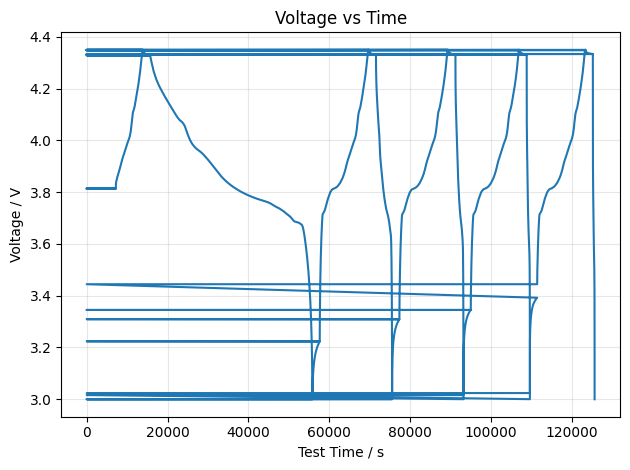

In [24]:
# Voltage vs Time
fig1 = line_plot(
    df_bdf,
    xdata="Test Time / s",
    ydata="Voltage / V",
    title="Voltage vs Time",
    save="out/voltage_vs_time.png",
)


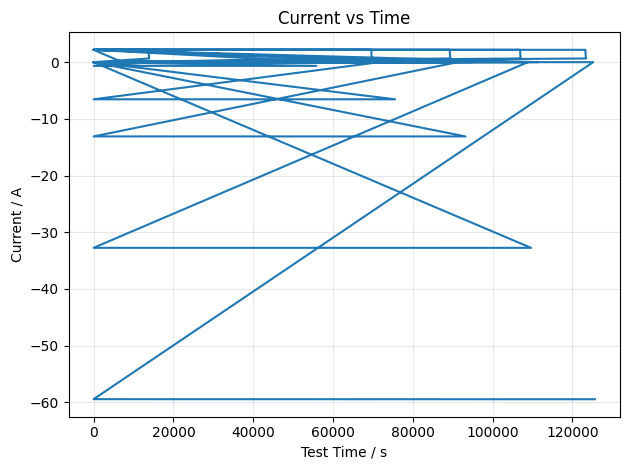

In [25]:
# Current vs Time
fig2 = line_plot(
    df_bdf,
    xdata="Test Time / s",
    ydata="Current / A",
    title="Current vs Time",
    save="out/current_vs_time.png",
)


### What BDF columns are available?


In [26]:
sorted(df_bdf.columns.tolist())


['Current / A', 'Step Time / s', 'Test Time / s', 'Voltage / V']

## (Alt) Load a BDF file directly and plot

If you already have a BDF CSV/Parquet, load with `bdf.io.load` and plot immediately.


True [] ['Minor non-monotonic time detected (19 drops).', 'Potential outliers in Current / A: 195 points (1.49%) flagged by robust MAD z>8.0. Examples: -32.7475, -32.7475, -32.7492']
Saved plot → out/vi_vs_time.png


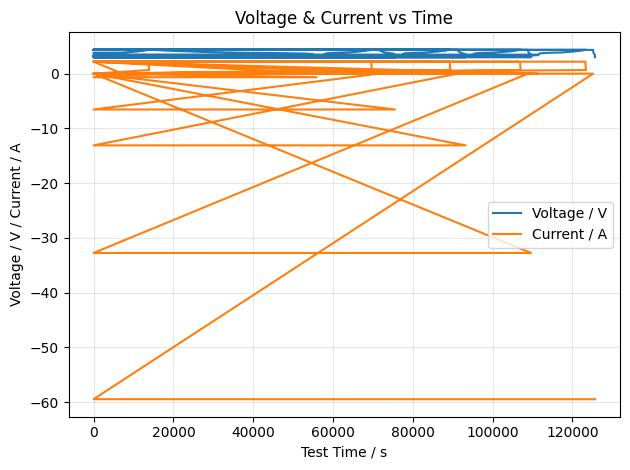

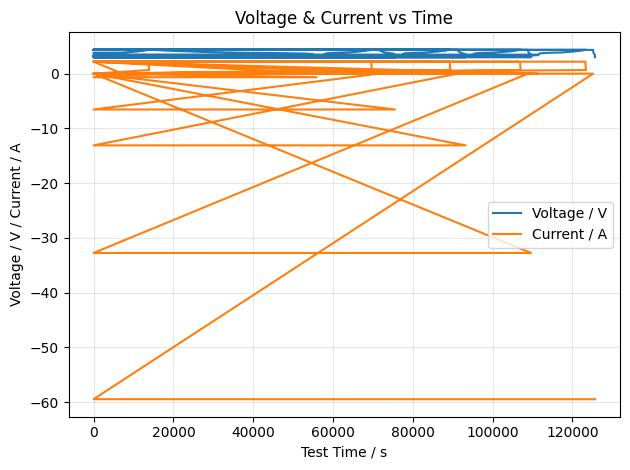

In [27]:
# validate an external file that claims to be BDF:
report = validate_bdf(BDF_OUT)
print(report.ok, report.errors, report.warnings)

df2 = load_bdf(BDF_OUT)

fig3 = line_plot(
    df2,
    xdata="Test Time / s",
    ydata=["Voltage / V", "Current / A"],
    title="Voltage & Current vs Time",
    save="out/vi_vs_time.png",
)
print("Saved plot → out/vi_vs_time.png")
fig3
